# ASSIGNMENT 1: App Insights Unlocked: A Data Analytics Challenge

# IMPORTING LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


# DATA CLEANING

## Step 1: Check Duplicate Records

### Find Total Duplicate Rows

In [3]:
df.duplicated().sum() 

np.int64(483)

### View Duplicate Rows

In [4]:
df[df.duplicated()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,Varies with device,"5,000,000+",Free,0,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up
236,Box,BUSINESS,4.2,159872,Varies with device,"10,000,000+",Free,0,Everyone,Business,"July 31, 2018",Varies with device,Varies with device
239,Google My Business,BUSINESS,4.4,70991,Varies with device,"5,000,000+",Free,0,Everyone,Business,"July 24, 2018",2.19.0.204537701,4.4 and up
256,ZOOM Cloud Meetings,BUSINESS,4.4,31614,37M,"10,000,000+",Free,0,Everyone,Business,"July 20, 2018",4.1.28165.0716,4.0 and up
261,join.me - Simple Meetings,BUSINESS,4.0,6989,Varies with device,"1,000,000+",Free,0,Everyone,Business,"July 16, 2018",4.3.0.508,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8643,Wunderlist: To-Do List & Tasks,PRODUCTIVITY,4.6,404610,Varies with device,"10,000,000+",Free,0,Everyone,Productivity,"April 6, 2018",Varies with device,Varies with device
8654,"TickTick: To Do List with Reminder, Day Planner",PRODUCTIVITY,4.6,25370,Varies with device,"1,000,000+",Free,0,Everyone,Productivity,"August 6, 2018",Varies with device,Varies with device
8658,ColorNote Notepad Notes,PRODUCTIVITY,4.6,2401017,Varies with device,"100,000,000+",Free,0,Everyone,Productivity,"June 27, 2018",Varies with device,Varies with device
10049,Airway Ex - Intubate. Anesthetize. Train.,MEDICAL,4.3,123,86M,"10,000+",Free,0,Everyone,Medical,"June 1, 2018",0.6.88,5.0 and up


### Verify Duplicate App Names

Before deleting duplicates, check whether some apps appear multiple times because of different versions.

In [5]:
df['App'].duplicated().sum()

np.int64(1181)

In [6]:
df[df['App'].duplicated(keep=False)].sort_values('App')

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1393,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
2322,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up
2543,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up
2256,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3.8M,"1,000+",Paid,$16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3103,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,Varies with device,"50,000,000+",Free,0,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device
3118,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,Varies with device,"50,000,000+",Free,0,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device
3202,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,Varies with device,"50,000,000+",Free,0,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device
3652,wetter.com - Weather and Radar,WEATHER,4.2,189313,38M,"10,000,000+",Free,0,Everyone,Weather,"August 6, 2018",Varies with device,Varies with device


### Remove Exact Duplicate

In [7]:
df = df.drop_duplicates()

In [8]:
df.shape

(10358, 13)

In [9]:
df.duplicated().sum()

np.int64(0)

## Step 2: Find the Corrupted Row

In [10]:
df[df['Rating'] > 5]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [11]:
df[df['Rating'] > 5].index

Index([10472], dtype='int64')

### Deleting Corrupted Row

In [12]:
df = df.drop(10472)

### Checking Corrupted Row

In [13]:
df[df['Rating'] > 5]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [14]:
df.shape

(10357, 13)

## Step 3: Missing Value Analysis

In [15]:
df.isnull().sum()

App                  0
Category             0
Rating            1465
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [16]:
round((df.isnull().sum()/len(df))*100,2)

App                0.00
Category           0.00
Rating            14.15
Reviews            0.00
Size               0.00
Installs           0.00
Type               0.01
Price              0.00
Content Rating     0.00
Genres             0.00
Last Updated       0.00
Current Ver        0.08
Android Ver        0.02
dtype: float64

### Investigate Small Missing-Value Columns First

In [17]:
df[df['Type'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
9148,Command & Conquer: Rivals,FAMILY,NaN,0,Varies with device,0,NaN,0,Everyone 10+,Strategy,"June 28, 2018",Varies with device,Varies with device


In [18]:
df[df['Current Ver'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
15,Learn To Draw Kawaii Characters,ART_AND_DESIGN,3.2,55,2.7M,"5,000+",Free,0,Everyone,Art & Design,"June 6, 2018",NaN,4.2 and up
1553,Market Update Helper,LIBRARIES_AND_DEMO,4.1,20145,11k,"1,000,000+",Free,0,Everyone,Libraries & Demo,"February 12, 2013",NaN,1.5 and up
6322,Virtual DJ Sound Mixer,TOOLS,4.2,4010,8.7M,"500,000+",Free,0,Everyone,Tools,"May 10, 2017",NaN,4.0 and up
6803,BT Master,FAMILY,NaN,0,222k,100+,Free,0,Everyone,Education,"November 6, 2016",NaN,1.6 and up
7333,Dots puzzle,FAMILY,4.0,179,14M,"50,000+",Paid,$0.99,Everyone,Puzzle,"April 18, 2018",NaN,4.0 and up
7407,Calculate My IQ,FAMILY,NaN,44,7.2M,"10,000+",Free,0,Everyone,Entertainment,"April 3, 2017",NaN,2.3 and up
7730,UFO-CQ,TOOLS,NaN,1,237k,10+,Paid,$0.99,Everyone,Tools,"July 4, 2016",NaN,2.0 and up
10342,La Fe de Jesus,BOOKS_AND_REFERENCE,NaN,8,658k,"1,000+",Free,0,Everyone,Books & Reference,"January 31, 2017",NaN,3.0 and up


In [19]:
df[df['Android Ver'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4453,[substratum] Vacuum: P,PERSONALIZATION,4.4,230,11M,"1,000+",Paid,$1.49,Everyone,Personalization,"July 20, 2018",4.4,NaN
4490,Pi Dark [substratum],PERSONALIZATION,4.5,189,2.1M,"10,000+",Free,0,Everyone,Personalization,"March 27, 2018",1.1,NaN


### Handling Missing Value

In [20]:
df['Current Ver'] = df['Current Ver'].fillna('Unknown')
df['Android Ver'] = df['Android Ver'].fillna('Unknown')
df['Type'] = df['Type'].fillna('Free')

In [21]:
df.isnull().sum()

App                  0
Category             0
Rating            1465
Reviews              0
Size                 0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          0
Android Ver          0
dtype: int64

## Step 4: Investigate Rating Missing Values

In [22]:
df['Rating'].describe()

count    8892.000000
mean        4.187877
std         0.522377
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

In [23]:
df['Rating'].median()

np.float64(4.3)

In [24]:
df['Rating'].mean()

np.float64(4.187876743139901)

<Axes: >

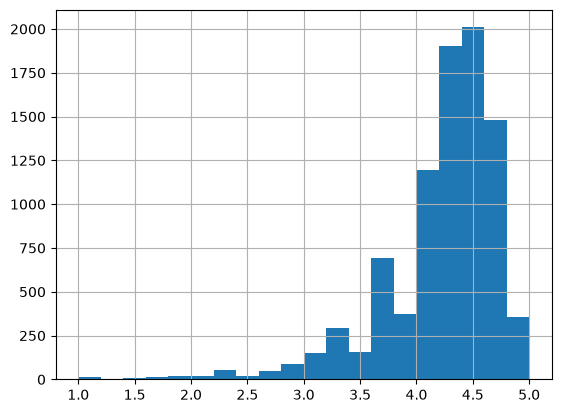

In [25]:
df['Rating'].hist(bins=20)

The statistics tell us:

1. Mean = 4.19
2. Median = 4.3
3. Ratings are concentrated between 4.0 and 4.5

Distribution is slightly skewed, so Median is safer than Mean.

However, for this we do not filling the Rating column yet.

Because

1. 14.15% missing values is quite high.
2. Rating is a key business metric.

Artificially filling 1465 ratings with 4.3 will create fake ratings and can bias EDA results.

## Step 5: Data Type Audit & Conversion

In [26]:
df.info()

<class 'pandas.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10357 non-null  str    
 1   Category        10357 non-null  str    
 2   Rating          8892 non-null   float64
 3   Reviews         10357 non-null  str    
 4   Size            10357 non-null  str    
 5   Installs        10357 non-null  str    
 6   Type            10357 non-null  str    
 7   Price           10357 non-null  str    
 8   Content Rating  10357 non-null  str    
 9   Genres          10357 non-null  str    
 10  Last Updated    10357 non-null  str    
 11  Current Ver     10357 non-null  str    
 12  Android Ver     10357 non-null  str    
dtypes: float64(1), str(12)
memory usage: 2.1 MB


### Convert Reviews to Integer

In [27]:
df['Reviews'].str.isnumeric().value_counts()

Reviews
True    10357
Name: count, dtype: int64

In [28]:
df['Reviews'] = pd.to_numeric(df['Reviews'])

In [29]:
df['Reviews'].dtype

dtype('int64')

In [30]:
df['Reviews'].describe()

count    1.035700e+04
mean     4.059046e+05
std      2.696778e+06
min      0.000000e+00
25%      3.200000e+01
50%      1.680000e+03
75%      4.641600e+04
max      7.815831e+07
Name: Reviews, dtype: float64

### Convert Installs to Numeric

In [31]:
df['Installs'].head()

0        10,000+
1       500,000+
2     5,000,000+
3    50,000,000+
4       100,000+
Name: Installs, dtype: str

In [32]:
df['Installs'] = df['Installs'].str.replace(',', '', regex=False)
df['Installs'] = df['Installs'].str.replace('+', '', regex=False)

In [33]:
df['Installs'].head()

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: str

In [34]:
df['Installs'] = pd.to_numeric(df['Installs'])

In [35]:
df['Installs'].dtype

dtype('int64')

### Convert Price to Float

In [36]:
df['Price'].head()

0    0
1    0
2    0
3    0
4    0
Name: Price, dtype: str

In [37]:
df['Price'].unique()[:10]

<ArrowStringArray>
[    '0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
 '$3.49', '$1.99']
Length: 10, dtype: str

In [38]:
# Remove $ sign
df['Price'] = df['Price'].str.replace('$', '', regex=False)

In [39]:
df['Price'].head()

0    0
1    0
2    0
3    0
4    0
Name: Price, dtype: str

In [40]:
df['Price'] = pd.to_numeric(df['Price'])

In [41]:
df['Price'].dtype

dtype('float64')

In [42]:
df['Price'].describe()

count    10357.000000
mean         1.030800
std         16.278625
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        400.000000
Name: Price, dtype: float64

In [43]:
df.info()

<class 'pandas.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10357 non-null  str    
 1   Category        10357 non-null  str    
 2   Rating          8892 non-null   float64
 3   Reviews         10357 non-null  int64  
 4   Size            10357 non-null  str    
 5   Installs        10357 non-null  int64  
 6   Type            10357 non-null  str    
 7   Price           10357 non-null  float64
 8   Content Rating  10357 non-null  str    
 9   Genres          10357 non-null  str    
 10  Last Updated    10357 non-null  str    
 11  Current Ver     10357 non-null  str    
 12  Android Ver     10357 non-null  str    
dtypes: float64(2), int64(2), str(9)
memory usage: 2.0 MB


### Convert Last Updated to Datetime

In [44]:
df['Last Updated'].head()

0     January 7, 2018
1    January 15, 2018
2      August 1, 2018
3        June 8, 2018
4       June 20, 2018
Name: Last Updated, dtype: str

In [45]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

In [46]:
df['Last Updated'].dtype

dtype('<M8[us]')

In [47]:
df['Last Updated'].head()

0   2018-01-07
1   2018-01-15
2   2018-08-01
3   2018-06-08
4   2018-06-20
Name: Last Updated, dtype: datetime64[us]

### Size Column Cleaning

In [48]:
df['Size'].head(20)

0      19M
1      14M
2     8.7M
3      25M
4     2.8M
5     5.6M
6      19M
7      29M
8      33M
9     3.1M
10     28M
11     12M
12     20M
13     21M
14     37M
15    2.7M
16    5.5M
17     17M
18     39M
19     31M
Name: Size, dtype: str

In [49]:
df['Size'].unique()[:20]

<ArrowStringArray>
[ '19M',  '14M', '8.7M',  '25M', '2.8M', '5.6M',  '29M',  '33M', '3.1M',
  '28M',  '12M',  '20M',  '21M',  '37M', '2.7M', '5.5M',  '17M',  '39M',
  '31M', '4.2M']
Length: 20, dtype: str

In [50]:
df['Size'].str.contains('Varies', na=False).sum()

np.int64(1526)

### Convert Size to MB

### First replace "Varies with device"

In [51]:
df['Size'] = df['Size'].replace('Varies with device', np.nan)

### Check KB Values

In [52]:
df[df['Size'].str.contains('k', na=False)].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
58,Restart Navigator,AUTO_AND_VEHICLES,4.0,1403,201k,100000,Free,0.0,Everyone,Auto & Vehicles,2014-08-26,1.0.1,2.2 and up
209,Plugin:AOT v5.0,BUSINESS,3.1,4034,23k,100000,Free,0.0,Everyone,Business,2015-09-11,3.0.1.11 (Build 311),2.2 and up
384,Hangouts Dialer - Call Phones,COMMUNICATION,4.0,122498,79k,10000000,Free,0.0,Everyone,Communication,2015-09-02,0.1.100944346,4.0.3 and up
450,Caller ID +,COMMUNICATION,4.0,9498,118k,1000000,Free,0.0,Everyone,Communication,2016-06-07,5.28.0,2.3 and up
458,GO Notifier,COMMUNICATION,4.2,124346,695k,10000000,Free,0.0,Everyone,Communication,2014-07-06,2.8,2.0 and up


In [53]:
df['Size'].str.contains('k', na=False).sum()

np.int64(315)

### Final Size Conversion to MB

In [54]:
def convert_size(size):
    if pd.isna(size):
        return np.nan
    elif 'M' in size:
        return float(size.replace('M', ''))
    elif 'k' in size:
        return float(size.replace('k', '')) / 1024
    else:
        return np.nan

In [55]:
df['Size'] = df['Size'].apply(convert_size)

In [56]:
df['Size'].dtype

dtype('float64')

In [57]:
df['Size'].head()

0    19.0
1    14.0
2     8.7
3    25.0
4     2.8
Name: Size, dtype: float64

### Check missing values:

In [58]:
df['Size'].isnull().sum()

np.int64(1526)

In [59]:
df['Size'].describe()

count    8831.000000
mean       21.287413
std        22.540591
min         0.008301
25%         4.700000
50%        13.000000
75%        29.000000
max       100.000000
Name: Size, dtype: float64

In [60]:
df.info()

<class 'pandas.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10357 non-null  str           
 1   Category        10357 non-null  str           
 2   Rating          8892 non-null   float64       
 3   Reviews         10357 non-null  int64         
 4   Size            8831 non-null   float64       
 5   Installs        10357 non-null  int64         
 6   Type            10357 non-null  str           
 7   Price           10357 non-null  float64       
 8   Content Rating  10357 non-null  str           
 9   Genres          10357 non-null  str           
 10  Last Updated    10357 non-null  datetime64[us]
 11  Current Ver     10357 non-null  str           
 12  Android Ver     10357 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(2), str(7)
memory usage: 1.8 MB


### Check for Negative Values

In [61]:
(df[['Rating','Reviews','Size','Installs','Price']] < 0).sum()

Rating      0
Reviews     0
Size        0
Installs    0
Price       0
dtype: int64

### Check Price Distribution

In [62]:
df['Price'].describe()

count    10357.000000
mean         1.030800
std         16.278625
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        400.000000
Name: Price, dtype: float64

### Check Install Distribution

In [63]:
df['Installs'].describe()

count    1.035700e+04
mean     1.415776e+07
std      8.023955e+07
min      0.000000e+00
25%      1.000000e+03
50%      1.000000e+05
75%      1.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64

## Step 6: Outlier Analysis

<Axes: xlabel='Rating'>

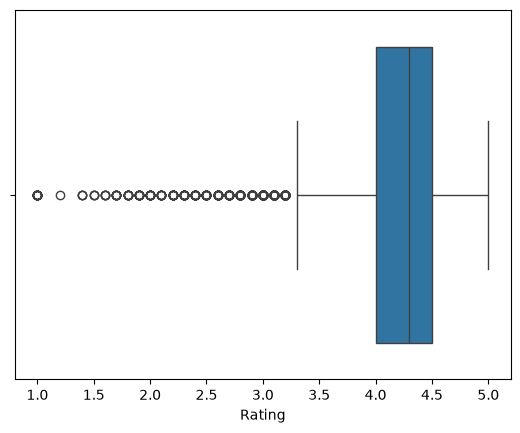

In [64]:
sns.boxplot(x=df['Rating'])

<Axes: xlabel='Reviews'>

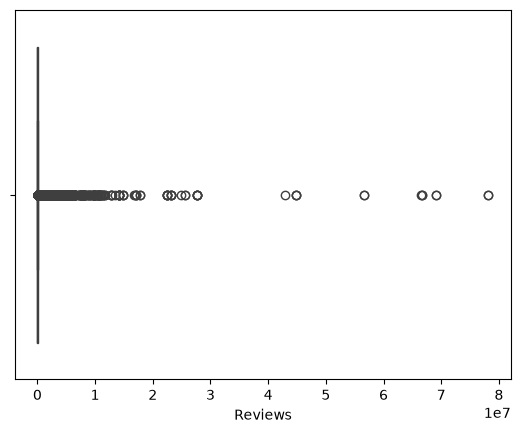

In [65]:
sns.boxplot(x=df['Reviews'])

<Axes: xlabel='Installs'>

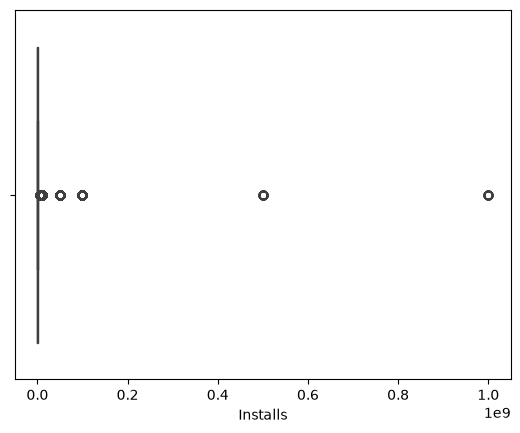

In [66]:
sns.boxplot(x=df['Installs'])

<Axes: xlabel='Price'>

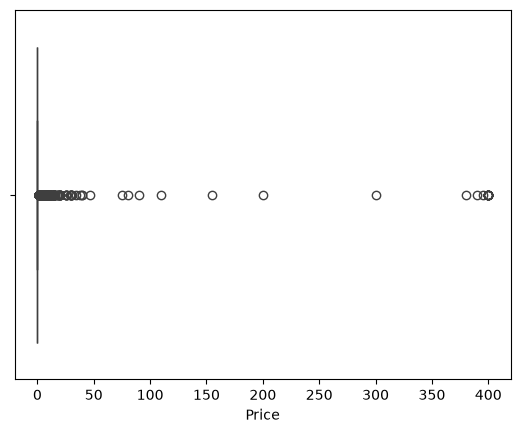

In [67]:
sns.boxplot(x=df['Price'])

<Axes: xlabel='Size'>

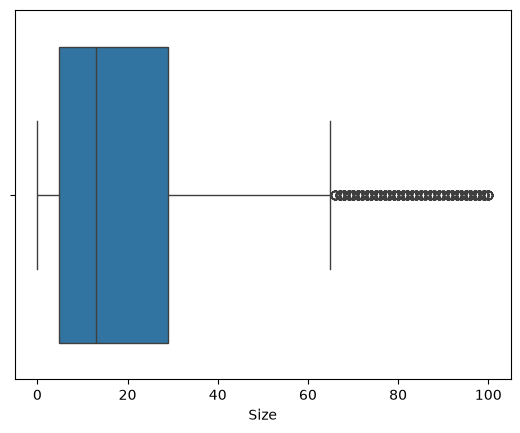

In [68]:
sns.boxplot(x=df['Size'])

In [69]:
df[['Rating','Reviews','Size','Installs','Price']].describe()

,Rating,Reviews,Size,Installs,Price
count,8892.000000,1.035700e+04,8831.000000,1.035700e+04,10357.000000
mean,4.187877,4.059046e+05,21.287413,1.415776e+07,1.030800
std,0.522377,2.696778e+06,22.540591,8.023955e+07,16.278625
min,1.000000,0.000000e+00,0.008301,0.000000e+00,0.000000
25%,4.000000,3.200000e+01,4.700000,1.000000e+03,0.000000
50%,4.300000,1.680000e+03,13.000000,1.000000e+05,0.000000
75%,4.500000,4.641600e+04,29.000000,1.000000e+06,0.000000
max,5.000000,7.815831e+07,100.000000,1.000000e+09,400.000000


In [70]:
df_cleaned = df.copy()

In [71]:
df_cleaned.to_csv('googleplaystore_cleaned.csv', index=False)

~95% of the data cleaning is complete.

Completed Cleaning Tasks

1. Removed exact duplicates	✅
2. Removed corrupted row (Rating = 19)	✅
3. Investigated missing values	✅
4. Filled Type	✅
5. Filled Current Ver	✅
6. Filled Android Ver	✅
7. Converted Reviews → int64	✅
8. Converted Installs → int64	✅
9. Converted Price → float64	✅
10. Converted Last Updated → datetime	✅
11. Converted Size → float64 (MB)	✅
12. Investigated Rating missing values	✅
13. Investigated Size missing values	✅
14. Decided to keep outliers	✅

Remaining Missing Values

1. Rating	1465	Keep as NaN
2. Size	1526	Keep as NaN ("Varies with device")

These are intentional missing values, not cleaning errors.

# BASIC LEVEL QUESTIONS

## 1. What is the average rating of apps in the dataset?

In [72]:
avg_rating = df_cleaned['Rating'].mean()
print("Average Rating:", round(avg_rating, 2))

Average Rating: 4.19


## 2. How many unique categories of apps are there?

In [73]:
unique_categories = df_cleaned['Category'].nunique()
print("Number of Unique Categories:", unique_categories)

Number of Unique Categories: 33


## 3. What is the distribution of app sizes?

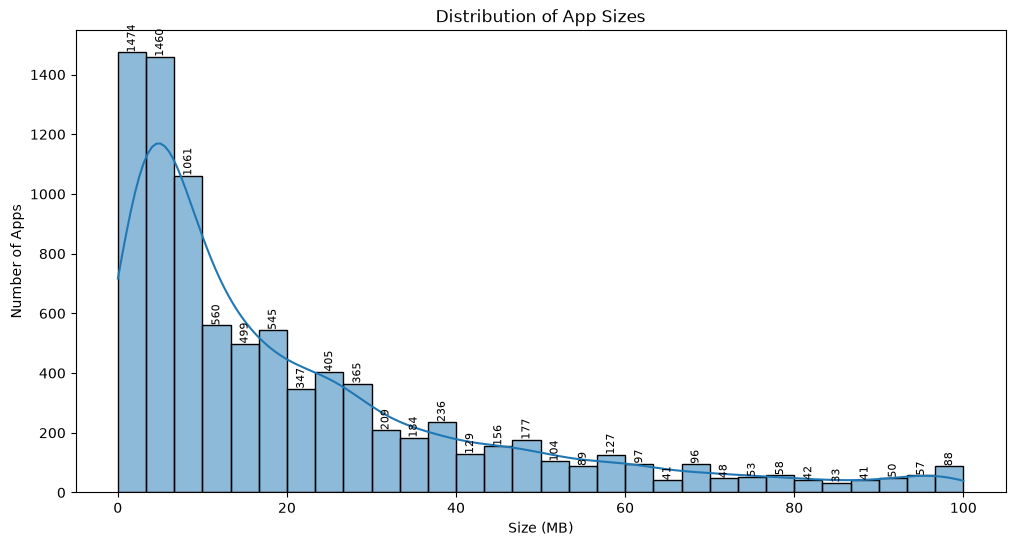

In [124]:
plt.figure(figsize=(12,6))

ax = sns.histplot(
    df_cleaned['Size'],
    bins=30,
    kde=True
)

# Add values on bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width()/2, height),
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=90
        )

plt.title("Distribution of App Sizes")
plt.xlabel("Size (MB)")
plt.ylabel("Number of Apps")

plt.show()

**Observation 1**

Most apps are concentrated between 0 MB and 20 MB.

**Observation 2**

The distribution is right-skewed (positively skewed):

- Many small-sized apps
- Fewer large-sized apps
- A long tail extending toward 100 MB

**Observation 3**

There are some apps with sizes between 60 MB and 100 MB, but they are relatively rare.

**Conclusion**

The distribution of app sizes is positively skewed. Most applications on the Google Play Store are lightweight (under 20 MB), while a smaller number of apps occupy significantly larger storage space. This suggests developers generally prefer smaller app sizes to improve download rates, reduce storage requirements, and enhance user experience.

**Business Impact**

- Smaller apps are easier to download, especially on slower networks.
- Lightweight apps consume less device storage, increasing user adoption.
- Large apps may offer richer features but can face installation barriers due to storage and bandwidth constraints.

## 4. How many free vs paid apps are there?

In [75]:
df_cleaned['Type'].value_counts()

Type
Free    9592
Paid     765
Name: count, dtype: int64

### Visualization

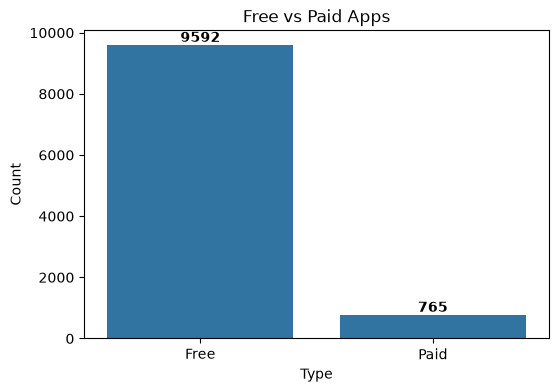

In [125]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Type', data=df_cleaned)

# Add count labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width()/2, height),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Free vs Paid Apps')
plt.xlabel('Type')
plt.ylabel('Count')

plt.show()

### Percentage Analysis

In [77]:
round(df_cleaned['Type'].value_counts(normalize=True)*100, 2)

Type
Free    92.61
Paid     7.39
Name: proportion, dtype: float64

**Business Insight**

- Free apps usually dominate the Google Play Store.
- Most developers use the freemium model, where the app is free but generates revenue through ads, subscriptions, or in-app purchases.
- Understanding the ratio of free vs paid apps helps analyze monetization strategies in the app market.

**Conclusion**

The Google Play Store contains significantly more free apps than paid apps. This indicates that developers prefer free distribution models to maximize downloads and user reach, while generating revenue through alternative monetization methods.

## 5. What is the most common content rating for apps?

In [78]:
most_common_rating = df_cleaned['Content Rating'].mode()[0]

print("Most Common Content Rating:", most_common_rating)

Most Common Content Rating: Everyone


### Frequency of All Content Ratings

In [79]:
df_cleaned['Content Rating'].value_counts()

Content Rating
Everyone           8382
Teen               1146
Mature 17+          447
Everyone 10+        377
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

### Visualization

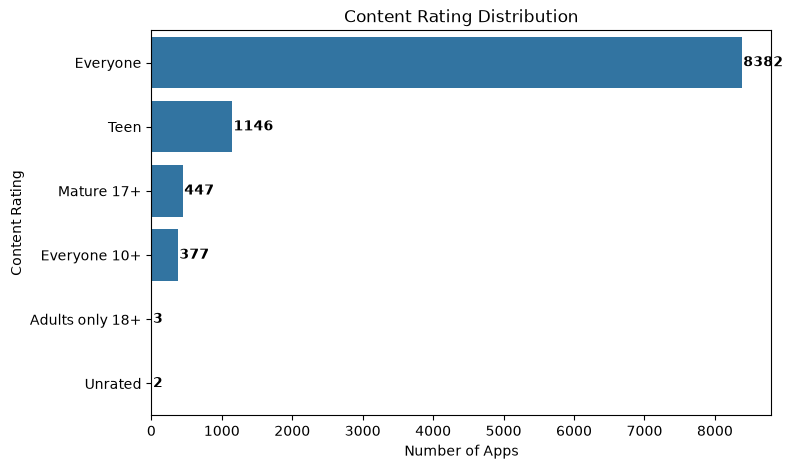

In [126]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    y='Content Rating',
    data=df_cleaned,
    order=df_cleaned['Content Rating'].value_counts().index
)

for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 20,  # space after bar
        p.get_y() + p.get_height()/2,
        f'{int(width)}',
        va='center',
        fontweight='bold'
    )

plt.title('Content Rating Distribution')
plt.xlabel('Number of Apps')
plt.ylabel('Content Rating')

plt.show()

**Business Insight**

- If Everyone is the most common rating, it indicates that most apps are designed for a broad audience.
- Developers often target the largest possible user base by creating family-friendly and universally accessible applications.
- Understanding the dominant content rating helps businesses align app development and marketing strategies with audience demand.

**Conclusion**

The most common content rating is Everyone, indicating that the majority of apps on the Google Play Store are suitable for users of all ages. This suggests developers prioritize reaching the widest possible audience.

## 6. What are the top 5 most installed apps?

In [81]:
top5_apps = df_cleaned[['App', 'Installs']].sort_values(
    by='Installs',
    ascending=False
).head(5)

top5_apps

,App,Installs
3454,Google Drive,1000000000
865,Google Play Games,1000000000
3523,Google Drive,1000000000
2544,Facebook,1000000000
2545,Instagram,1000000000


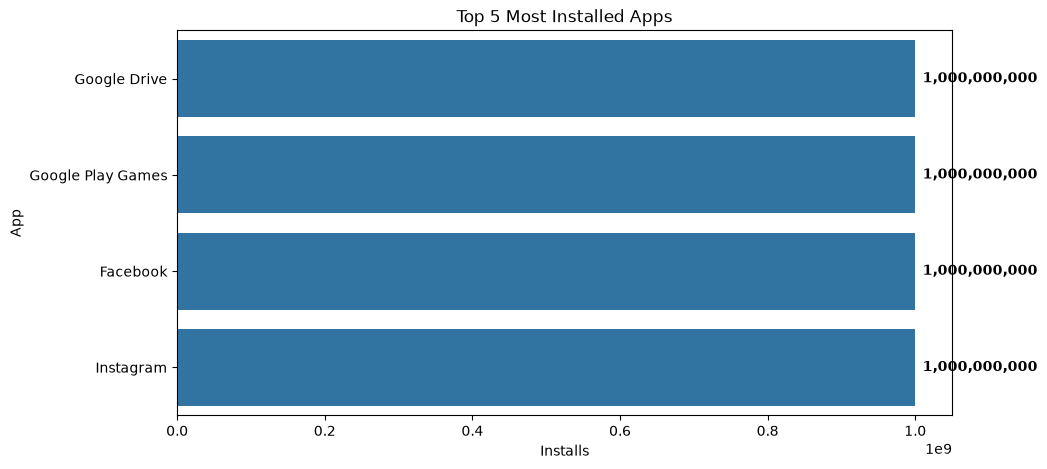

In [127]:
top5_apps = df_cleaned[['App','Installs']].sort_values(
    by='Installs',
    ascending=False
).head(5)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=top5_apps,
    x='Installs',
    y='App'
)

# Add install values
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 10000000,  # space after bar
        p.get_y() + p.get_height()/2,
        f'{width:,.0f}',
        va='center',
        fontweight='bold'
    )

plt.title('Top 5 Most Installed Apps')
plt.xlabel('Installs')
plt.ylabel('App')

plt.show()

**Business Insight**

- If Everyone is the most common rating, it indicates that most apps are designed for a broad audience.
- Developers often target the largest possible user base by creating family-friendly and universally accessible applications.
- Understanding the dominant content rating helps businesses align app development and marketing strategies with audience demand.

**Conclusion**

The most common content rating is Everyone, indicating that the majority of apps on the Google Play Store are suitable for users of all ages. This suggests developers prioritize reaching the widest possible audience.

## 7. How many apps have a rating of 4.0 and above?

In [83]:
apps_above_4 = df_cleaned[df_cleaned['Rating'] >= 4.0].shape[0]

print("Apps with Rating 4.0 and Above:", apps_above_4)

Apps with Rating 4.0 and Above: 6947


### Percentage Analysis

In [84]:
round(
    (df_cleaned['Rating'] >= 4.0).sum()
    / df_cleaned['Rating'].count() * 100,
    2
)

np.float64(78.13)

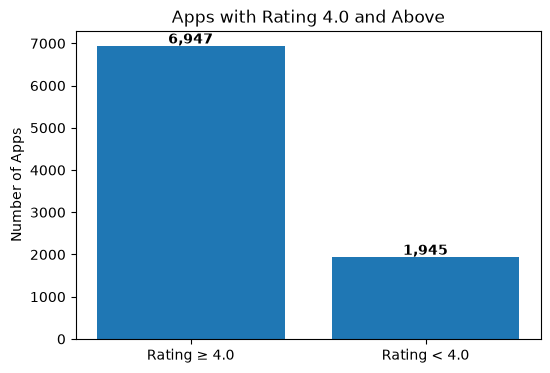

In [128]:
counts = [
    (df_cleaned['Rating'] >= 4.0).sum(),
    (df_cleaned['Rating'] < 4.0).sum()
]

labels = ['Rating ≥ 4.0', 'Rating < 4.0']

plt.figure(figsize=(6,4))

ax = plt.bar(labels, counts)

# Add value labels
for bar in ax:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 50,
        f'{int(height):,}',
        ha='center',
        fontweight='bold'
    )

plt.title('Apps with Rating 4.0 and Above')
plt.ylabel('Number of Apps')

plt.show()

**Business Insight**

- Apps with ratings 4.0 and above are generally considered well-received by users.
- A large number of highly rated apps indicates strong overall user satisfaction.
- Developers can analyze these apps to understand features and practices that contribute to positive user experiences.

**Conclusion**

Apps with a rating of 4.0 and above represent the high-quality segment of the Google Play Store. These apps generally enjoy better user satisfaction and can serve as benchmarks for future app development.

## 8. What is the average number of reviews for free vs paid apps?

In [86]:
avg_reviews = df_cleaned.groupby('Type')['Reviews'].mean().round(2)

print(avg_reviews)

Type
Free    437328.00
Paid     11900.55
Name: Reviews, dtype: float64


### Visualization

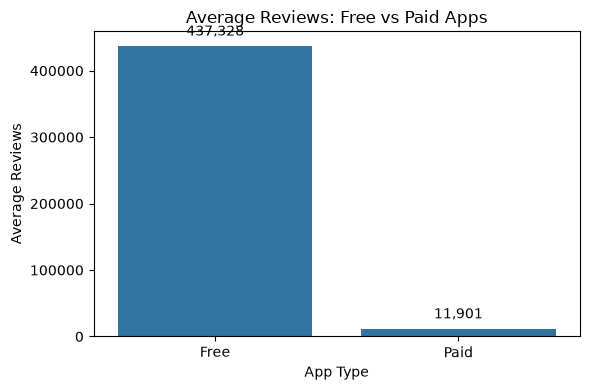

In [129]:
avg_reviews = df_cleaned.groupby('Type')['Reviews'].mean().reset_index()

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=avg_reviews,
    x='Type',
    y='Reviews'
)

plt.title('Average Reviews: Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Average Reviews')

# Add values on bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

**Business Insight**

- Higher average reviews generally indicate higher user engagement.
- If free apps have significantly more reviews, it suggests that free apps attract a larger audience and generate more user feedback.
- This information can help businesses choose between free and paid monetization strategies.

**Conclusion Template**

By comparing the average number of reviews for free and paid apps, we can evaluate user engagement levels. Apps with higher average reviews typically reach a larger audience and receive more interaction from users.

## 9. What is the average app size for each category?

In [88]:
avg_size_category = (
    df_cleaned.groupby('Category')['Size']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

avg_size_category

Category
GAME                   44.13
FAMILY                 27.93
TRAVEL_AND_LOCAL       24.52
SPORTS                 24.18
ENTERTAINMENT          22.64
PARENTING              22.51
FOOD_AND_DRINK         22.06
HEALTH_AND_FITNESS     21.64
EDUCATION              20.08
AUTO_AND_VEHICLES      20.04
MEDICAL                19.38
FINANCE                17.94
SOCIAL                 16.88
PHOTOGRAPHY            16.83
MAPS_AND_NAVIGATION    16.61
VIDEO_PLAYERS          16.08
HOUSE_AND_HOME         15.97
SHOPPING               15.90
DATING                 15.83
LIFESTYLE              14.86
EVENTS                 13.96
BUSINESS               13.91
BEAUTY                 13.80
COMICS                 13.48
BOOKS_AND_REFERENCE    13.19
WEATHER                13.12
PRODUCTIVITY           12.87
NEWS_AND_MAGAZINES     12.65
ART_AND_DESIGN         12.37
COMMUNICATION          11.66
PERSONALIZATION        11.29
LIBRARIES_AND_DEMO     11.08
TOOLS                   8.77
Name: Size, dtype: float64

### Top 10 Categories with Largest Average App Size

In [89]:
avg_size_category.head(10)

Category
GAME                  44.13
FAMILY                27.93
TRAVEL_AND_LOCAL      24.52
SPORTS                24.18
ENTERTAINMENT         22.64
PARENTING             22.51
FOOD_AND_DRINK        22.06
HEALTH_AND_FITNESS    21.64
EDUCATION             20.08
AUTO_AND_VEHICLES     20.04
Name: Size, dtype: float64

### Visualization

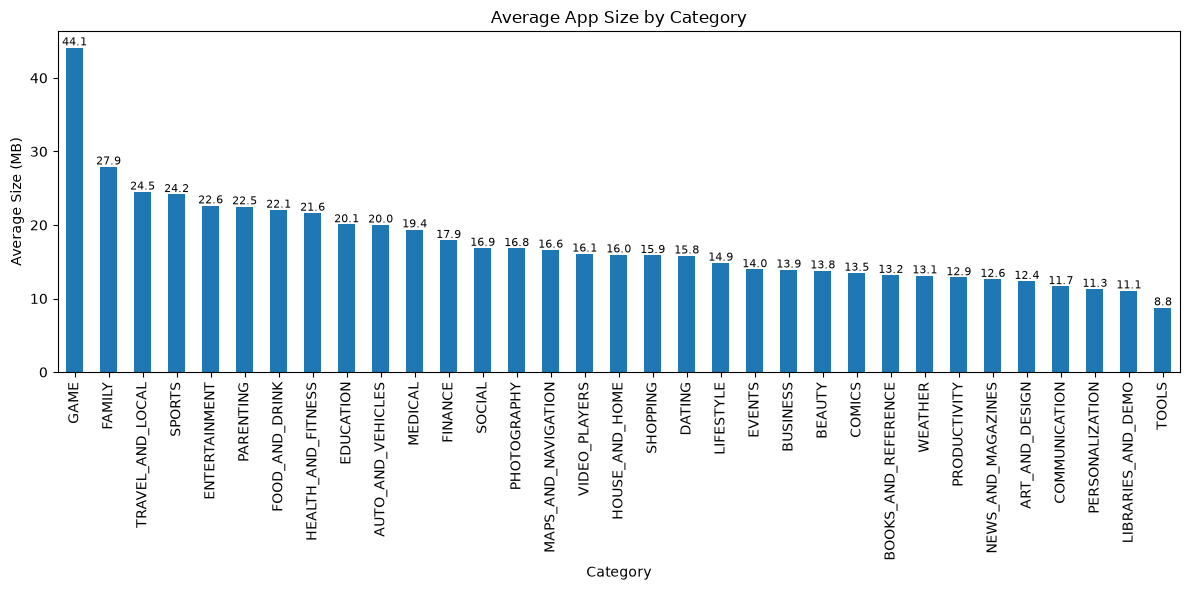

In [130]:
avg_size_category = (
    df_cleaned.groupby('Category')['Size']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

ax = avg_size_category.plot(kind='bar')

plt.title('Average App Size by Category')
plt.xlabel('Category')
plt.ylabel('Average Size (MB)')
plt.xticks(rotation=90)

# Add values on bars
for i, value in enumerate(avg_size_category):
    ax.text(
        i,                    # x-position
        value + 0.3,          # y-position
        f'{value:.1f}',       # value format
        ha='center',
        fontsize=8
    )

plt.tight_layout()
plt.show()

**Business Insight**

- Categories with larger average app sizes may include more multimedia content, graphics, videos, or advanced features.
- Categories with smaller app sizes are generally lightweight and easier to download.
- Understanding category-wise size trends helps developers optimize storage requirements and user experience.

**Conclusion Template**

The average app size varies significantly across categories. Categories with larger average sizes may require more device storage and network bandwidth, while categories with smaller average sizes tend to be more accessible to users with limited storage or slower internet connections.

## 10. How many apps were last updated in 2018?

In [91]:
apps_2018 = df_cleaned[df_cleaned['Last Updated'].dt.year == 2018]

print("Apps Updated in 2018:", apps_2018.shape[0])

Apps Updated in 2018: 6934


### Visualization

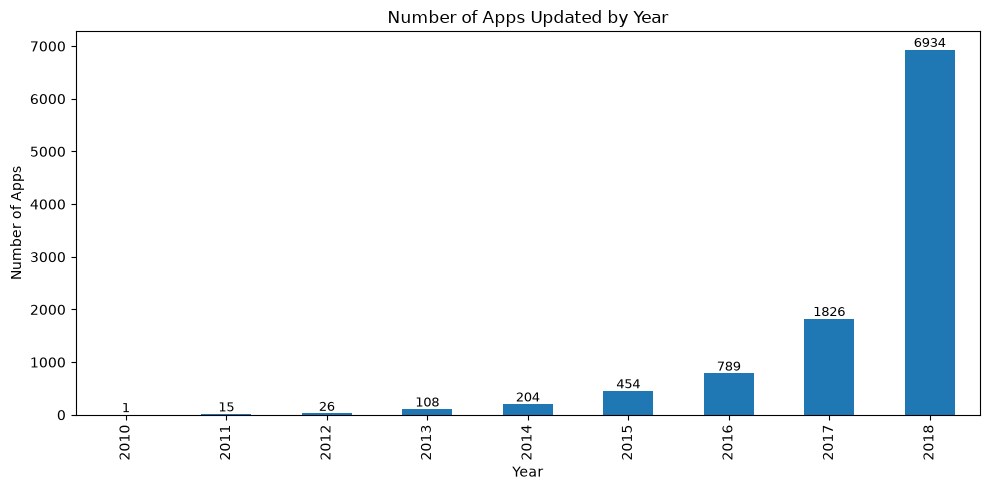

In [131]:
yearly_updates = (
    df_cleaned['Last Updated']
    .dt.year
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

ax = yearly_updates.plot(kind='bar')

plt.title('Number of Apps Updated by Year')
plt.xlabel('Year')
plt.ylabel('Number of Apps')

# Add values on bars
for i, value in enumerate(yearly_updates):
    ax.text(
        i,              # x-position
        value + 50,     # y-position
        str(value),     # label
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Business Insight**

- Frequent updates indicate active maintenance and developer engagement.
- Apps updated recently are more likely to remain compatible with newer Android versions and user expectations.
- Understanding update patterns helps identify periods of high development activity.

**Conclusion Template**

The number of apps updated in 2018 reflects the level of developer activity during that year. A high count suggests that developers actively maintained and improved their applications, helping ensure better performance, security, and user satisfaction.

# MEDIUM LEVEL QUESTIONS

## 1. What is the correlation between the number of installs and the app rating?

In [93]:
correlation = df_cleaned['Installs'].corr(df_cleaned['Rating'])
print(round(correlation, 4))

0.0509


### Visualization

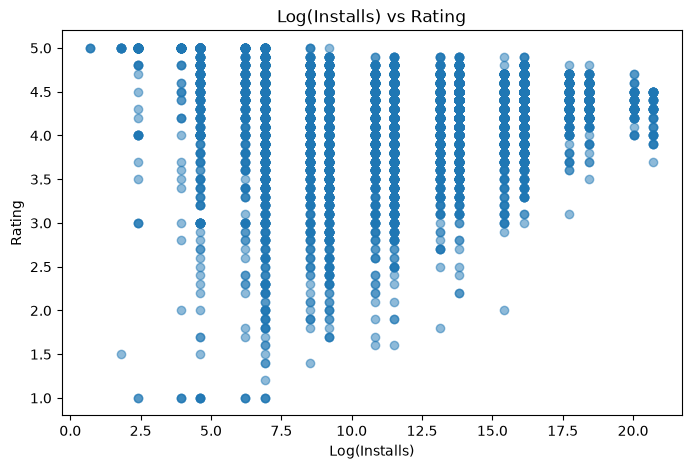

In [94]:
plt.figure(figsize=(8,5))

plt.scatter(
    np.log1p(df_cleaned['Installs']),
    df_cleaned['Rating'],
    alpha=0.5
)

plt.title('Log(Installs) vs Rating')
plt.xlabel('Log(Installs)')
plt.ylabel('Rating')

plt.show()

**Business Insight**

- High installs do not guarantee high ratings.
- Marketing can increase downloads, but maintaining high ratings requires a good user experience.
- Developers should focus on both acquisition (installs) and retention/satisfaction (ratings).

**Conclusion**

There is a very weak positive relationship between app installs and app ratings. This suggests that apps with more downloads do not necessarily receive higher ratings. User satisfaction depends on many other factors such as app quality, user experience, features, performance, and customer support.

**Observation from Log(Installs) Plot**

Transformed scatter plot is much better than the original.

It shows:

- Ratings are concentrated between 3.5 and 5.0 across almost all install levels.
- Both low-install and high-install apps can have high ratings.
- No clear upward trend is visible, which supports the low correlation value (0.0509).

## 2. Which app categories have the highest average rating?

In [95]:
top_10_categories = (
    df_cleaned.groupby('Category')['Rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(top_10_categories)

Category
EVENTS                 4.435556
EDUCATION              4.375969
ART_AND_DESIGN         4.358065
BOOKS_AND_REFERENCE    4.347458
PERSONALIZATION        4.333871
PARENTING              4.300000
GAME                   4.281285
BEAUTY                 4.278571
HEALTH_AND_FITNESS     4.261450
SOCIAL                 4.254918
Name: Rating, dtype: float64


### Visualization

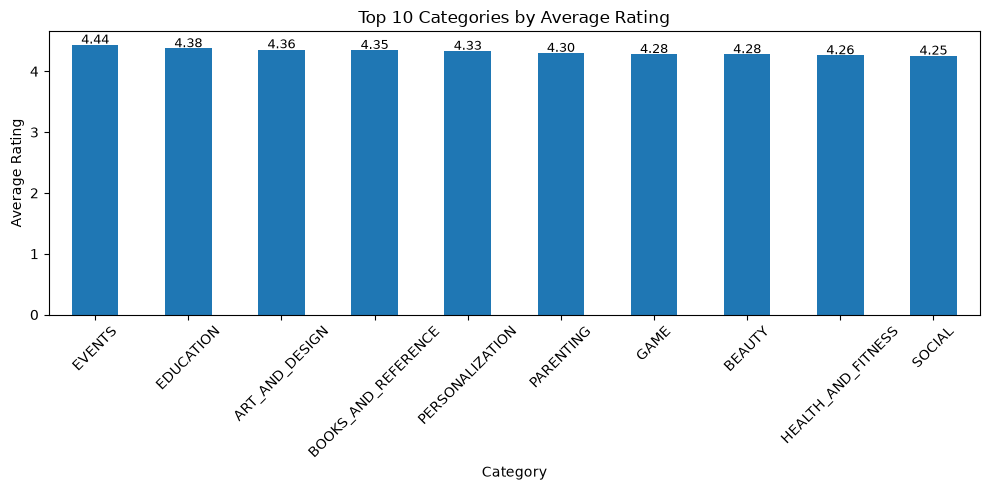

In [132]:
top_10_categories = (
    df_cleaned.groupby('Category')['Rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

ax = top_10_categories.plot(kind='bar')

plt.title('Top 10 Categories by Average Rating')
plt.xlabel('Category')
plt.ylabel('Average Rating')

# Add values on bars
for i, value in enumerate(top_10_categories):
    ax.text(
        i,                 # x-position
        value + 0.02,      # y-position
        f'{value:.2f}',    # show 2 decimal places
        ha='center',
        fontsize=9
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Business Insight**

- Education and Art & Design apps receive strong user appreciation, indicating high engagement and satisfaction.
- Events apps achieve the highest ratings, suggesting users value functionality and usefulness in event management applications.
- Developers entering these categories can study successful apps to understand features that drive positive user feedback.

**Conclusion**

The Events category has the highest average rating (4.44), followed by Education and Art & Design. These categories demonstrate the highest levels of user satisfaction and may represent attractive areas for app development and investment.

## 3. How does the price of an app affect its average rating?

### Calculate Average Rating by Price

In [97]:
paid_apps = df_cleaned[df_cleaned['Price'] > 0]

price_rating = (
    paid_apps.groupby('Price')['Rating']
    .mean()
    .sort_values(ascending=False)
)

price_rating.head(10)

Price
3.04     5.00
1.75     5.00
2.50     4.80
2.59     4.70
15.99    4.70
19.40    4.70
3.90     4.70
10.00    4.65
14.00    4.60
3.88     4.60
Name: Rating, dtype: float64

### Check Correlation Between Price and Rating

In [98]:
correlation = paid_apps['Price'].corr(paid_apps['Rating'])

print("Correlation:", round(correlation, 4))

Correlation: -0.1126


### Visualization

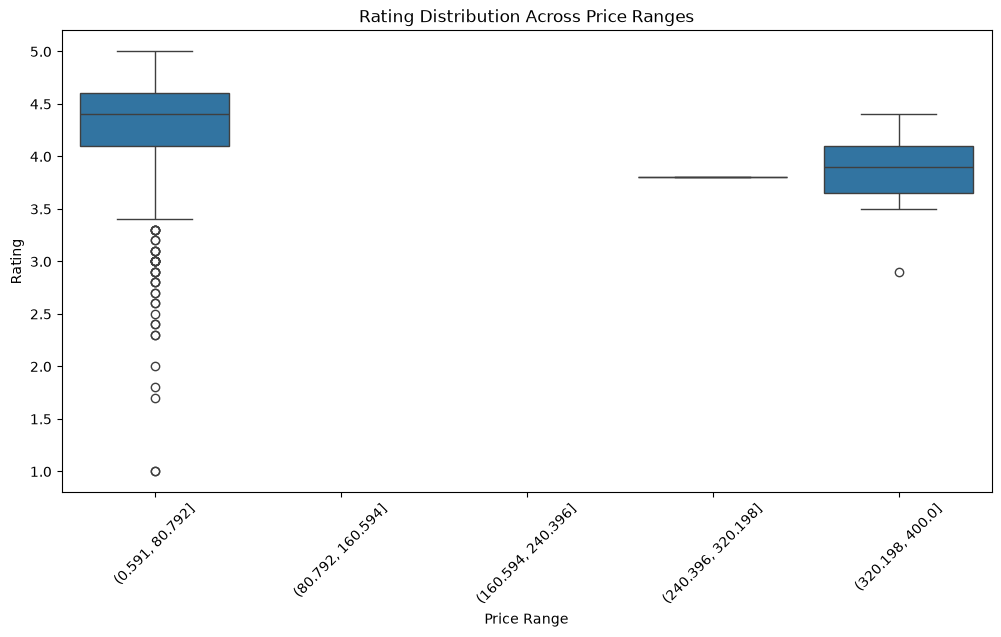

In [99]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x=pd.cut(paid_apps['Price'], bins=5),
    y=paid_apps['Rating']
)

plt.title('Rating Distribution Across Price Ranges')
plt.xlabel('Price Range')
plt.ylabel('Rating')

plt.xticks(rotation=45)
plt.show()

**Observation from the Boxplot**

- Most paid apps have ratings between 4.0 and 4.6.
- Higher-priced apps do not consistently receive higher ratings.
- The median ratings across price ranges are quite similar.


- A few low-rated paid apps exist in the lower price ranges, creating some outliers.

**Business Insight**

- Premium pricing alone does not improve customer satisfaction.
- Developers should focus on delivering value and quality rather than relying on higher prices.
- Competitive pricing combined with a strong user experience is more likely to produce positive ratings.

**Conclusion**

There is a very weak negative correlation (-0.1126) between app price and app rating. This suggests that increasing the price of an app does not lead to higher user ratings. Users appear to evaluate apps primarily based on quality, features, and experience rather than price.


## 4. What is the distribution of app ratings across different content ratings?

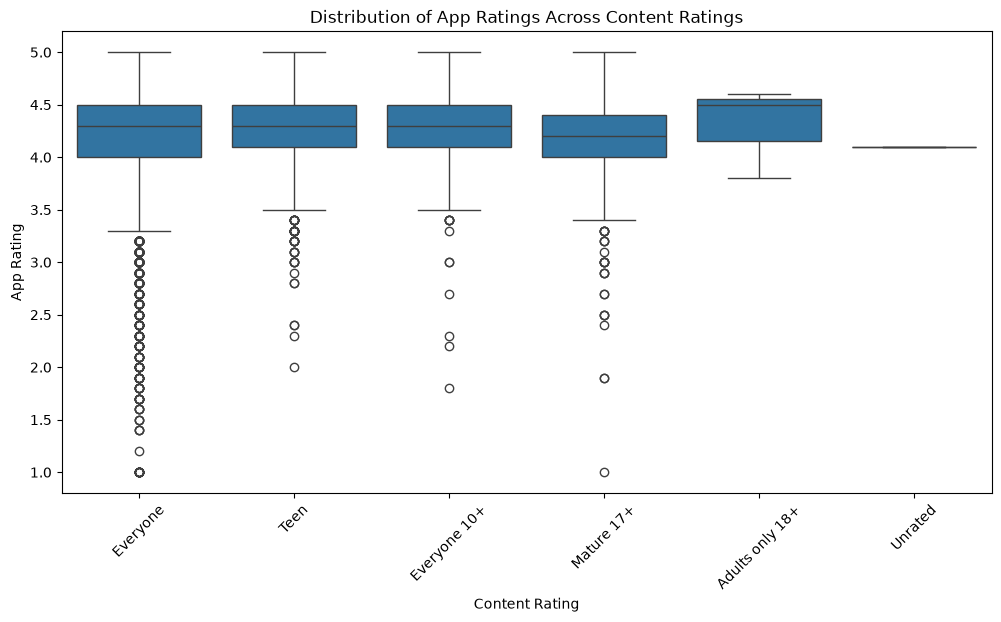

In [100]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_cleaned,
    x='Content Rating',
    y='Rating'
)

plt.title('Distribution of App Ratings Across Content Ratings')
plt.xlabel('Content Rating')
plt.ylabel('App Rating')

plt.xticks(rotation=45)
plt.show()

In [101]:
content_rating_avg = (
    df_cleaned.groupby('Content Rating')['Rating']
    .mean()
    .sort_values(ascending=False)
)

print(content_rating_avg)

Content Rating
Adults only 18+    4.300000
Everyone 10+       4.254167
Teen               4.238845
Everyone           4.180817
Mature 17+         4.124331
Unrated            4.100000
Name: Rating, dtype: float64


**Business Insight**

- High user satisfaction can be achieved across all target audiences.
- Developers should prioritize app quality and user experience instead of relying on content targeting alone.
- Categories such as Everyone 10+ and Teen show strong performance and may offer attractive opportunities for development and marketing.
- Project

**Conclusion**

App ratings remain consistently high across different content-rating categories, ranging from 4.10 to 4.30. The "Adults only 18+" category has the highest average rating, while "Everyone 10+" and "Teen" categories also perform strongly. Overall, content rating has minimal impact on app ratings, indicating that app quality is a more important driver of user satisfaction.

## 5. Which genres have the most apps with over 1 million installs?

### Filter Apps with More Than 1 Million Installs

In [102]:
apps_1m = df_cleaned[df_cleaned['Installs'] > 1000000]

### Count Apps by Genre

In [103]:
top_genres = (
    apps_1m.groupby('Genres')
    .size()
    .sort_values(ascending=False)
)

print(top_genres.head(10))

Genres
Tools            187
Action           182
Photography      161
Communication    146
Productivity     124
Arcade           113
Sports           109
Social           107
Entertainment    103
Shopping          91
dtype: int64


### Visualization

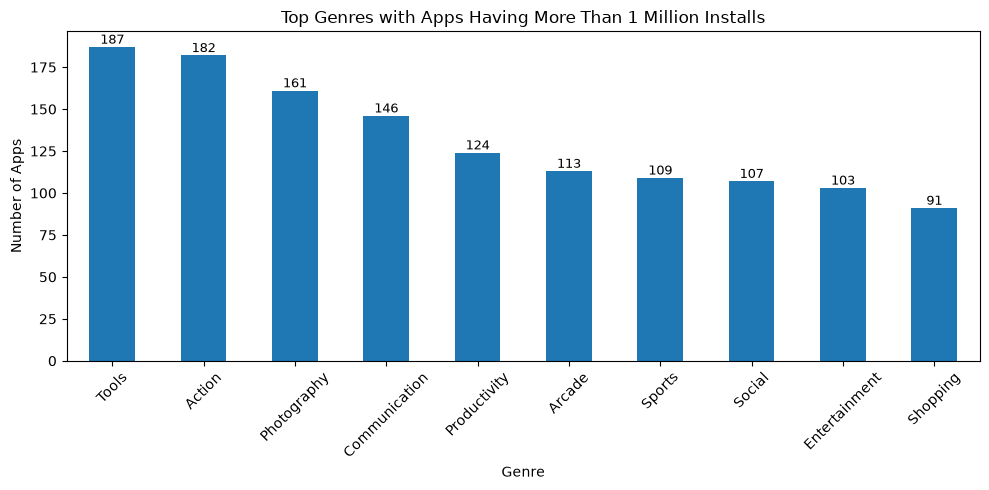

In [133]:
top_10_genres = (
    apps_1m.groupby('Genres')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

ax = top_10_genres.plot(kind='bar')

plt.title('Top Genres with Apps Having More Than 1 Million Installs')
plt.xlabel('Genre')
plt.ylabel('Number of Apps')

# Add values on bars
for i, value in enumerate(top_10_genres):
    ax.text(
        i,               # x-position
        value + 2,       # y-position
        str(value),      # label
        ha='center',
        fontsize=9
    )

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Business Insight**

- Developers looking for large user bases may consider Tools, Communication, and Productivity categories.
- Gaming genres such as Action and Arcade show strong adoption potential.
- Marketing efforts can be focused on genres with historically high install volumes.
- Project

**Conclusion**

The Tools genre contains the highest number of apps with more than 1 million installs, followed by Action, Photography, and Communication. This indicates that both utility-based and entertainment-based applications have strong adoption rates. Developers can use these insights to identify high-demand segments within the app marketplace.

## 6. How frequently do apps get updated? Calculate the average time between updates.

In [105]:
df_cleaned['Update_Year'] = df_cleaned['Last Updated'].dt.year

updates_per_year = (
    df_cleaned['Update_Year']
    .value_counts()
    .sort_index()
)

print(updates_per_year)

Update_Year
2010       1
2011      15
2012      26
2013     108
2014     204
2015     454
2016     789
2017    1826
2018    6934
Name: count, dtype: int64


### Visualization

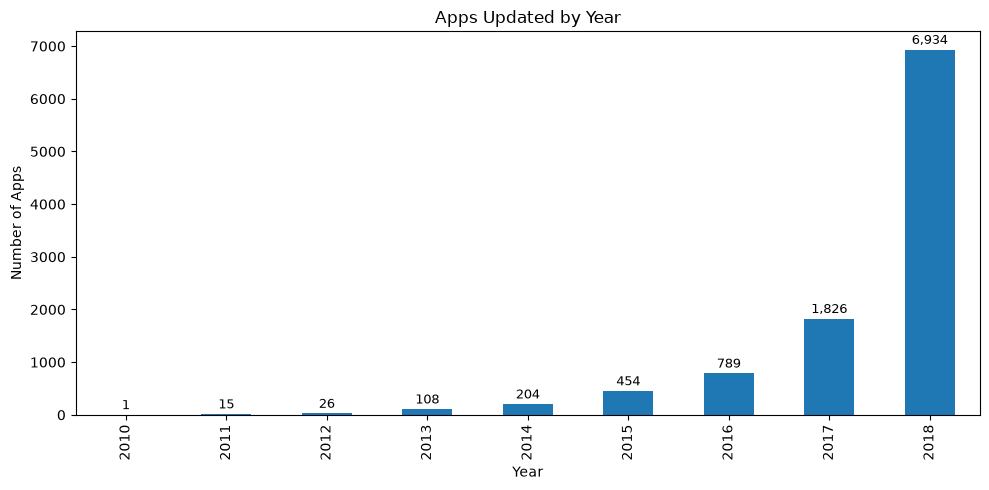

In [134]:
plt.figure(figsize=(10,5))

ax = updates_per_year.plot(kind='bar')

plt.title('Apps Updated by Year')
plt.xlabel('Year')
plt.ylabel('Number of Apps')

# Add values on bars
for i, value in enumerate(updates_per_year):
    ax.text(
        i,                  # x position
        value + 50,         # y position
        f'{value:,}',       # format with commas
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Business Insight**

Frequent updates are associated with:

- Better user engagement
- Bug fixes and security improvements
- Compatibility with newer Android versions
- Higher chances of retaining users

**Conclusion**

The majority of apps were updated in 2018, indicating that developers increasingly focused on maintaining and improving their applications. This trend highlights the importance of regular updates for user retention and app performance.

## 7. What is the impact of app size on the number of installs?

### Calculate Correlation

In [107]:
correlation = df_cleaned['Size'].corr(df_cleaned['Installs'])

print("Correlation:", round(correlation, 4))

Correlation: 0.1689


### Visualization

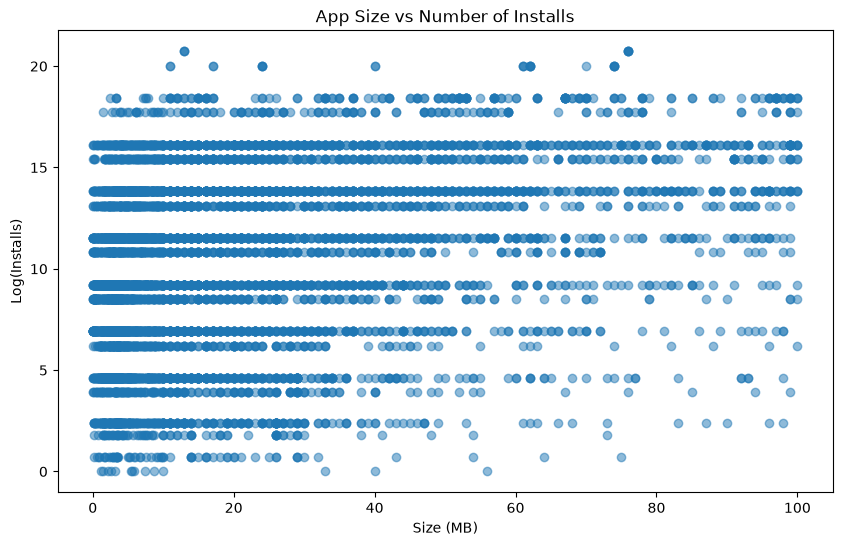

In [108]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_cleaned['Size'],
    np.log1p(df_cleaned['Installs']),  # log scale for better visibility
    alpha=0.5
)

plt.title('App Size vs Number of Installs')
plt.xlabel('Size (MB)')
plt.ylabel('Log(Installs)')

plt.show()

**Business Insight**

Developers should focus more on app quality, functionality, ratings, and user experience rather than only reducing app size. While optimizing size remains important for performance and storage efficiency, it is not the primary factor driving app downloads.

**Conclusion**

There is little evidence that app size significantly impacts the number of installs. Both small and large applications can achieve high download volumes.

## 8. Which apps have the highest number of reviews, and what are their ratings?

In [109]:
top_reviewed_apps = (
    df_cleaned[['App', 'Reviews', 'Rating']]
    .sort_values(by='Reviews', ascending=False)
    .head(10)
)

print(top_reviewed_apps)

                                           App   Reviews  Rating
2544                                  Facebook  78158306     4.1
3943                                  Facebook  78128208     4.1
336                         WhatsApp Messenger  69119316     4.4
3904                        WhatsApp Messenger  69109672     4.4
2604                                 Instagram  66577446     4.5
2545                                 Instagram  66577313     4.5
3909                                 Instagram  66509917     4.5
382   Messenger – Text and Video Chat for Free  56646578     4.0
335   Messenger – Text and Video Chat for Free  56642847     4.0
1879                            Clash of Clans  44893888     4.6


### Visualization

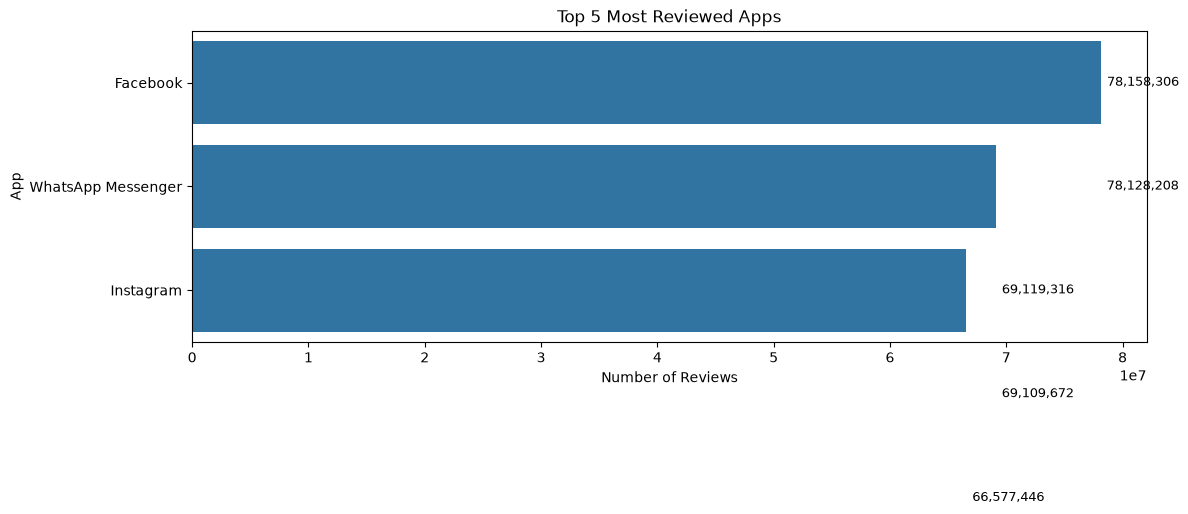

In [139]:
top_reviewed_apps = (
    df_cleaned[['App', 'Reviews', 'Rating']]
    .sort_values(by='Reviews', ascending=False)
    .head(5)      # Same number as chart
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_reviewed_apps,
    x='Reviews',
    y='App'
)

plt.title('Top 5 Most Reviewed Apps')
plt.xlabel('Number of Reviews')
plt.ylabel('App')

# Add labels
for index, row in top_reviewed_apps.iterrows():
    ax.text(
        row['Reviews'] + 500000,      # slight offset
        list(top_reviewed_apps.index).index(index),
        f"{row['Reviews']:,}",
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Business Insight**

- High review counts indicate strong user engagement.
- Popular apps continuously collect feedback, helping developers improve features and user experience.
- New app developers can study these successful apps to understand user retention, engagement strategies, and feature adoption.

**Conclusion**

The most reviewed apps belong primarily to the Social, Communication, and Gaming categories. These applications attract millions of active users and consequently accumulate very large numbers of reviews.

## 9. How does the content rating distribution differ between free and paid apps?

### Create Crosstab

In [111]:
content_type_dist = pd.crosstab(
    df_cleaned['Content Rating'],
    df_cleaned['Type']
)

print(content_type_dist)

Type             Free  Paid
Content Rating             
Adults only 18+     3     0
Everyone         7720   662
Everyone 10+      345    32
Mature 17+        428    19
Teen             1094    52
Unrated             2     0


### Percentage Distribution

In [112]:
content_type_pct = pd.crosstab(
    df_cleaned['Content Rating'],
    df_cleaned['Type'],
    normalize='columns'
) * 100

print(round(content_type_pct, 2))

Type              Free   Paid
Content Rating               
Adults only 18+   0.03   0.00
Everyone         80.48  86.54
Everyone 10+      3.60   4.18
Mature 17+        4.46   2.48
Teen             11.41   6.80
Unrated           0.02   0.00


### Visualization

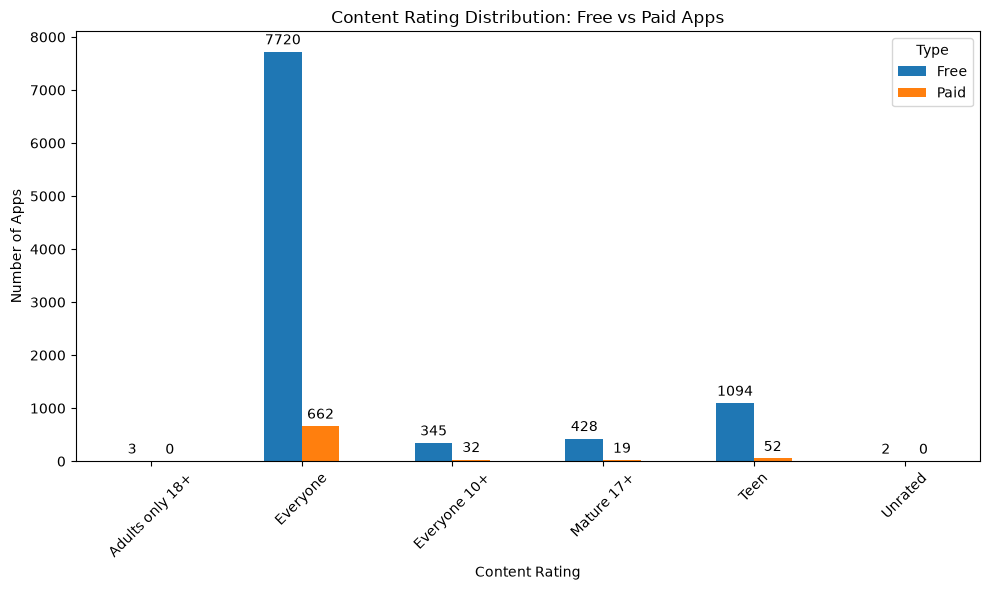

In [140]:
ax = content_type_dist.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Content Rating Distribution: Free vs Paid Apps')
plt.xlabel('Content Rating')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

**Business Insight**

- Developers maximize reach by targeting the Everyone audience.
- Free apps are the preferred business model across all age groups.
- Companies seeking larger user bases should prioritize family-friendly and universally accessible content.
- The relatively small number of paid apps suggests that monetization strategies such as advertisements, subscriptions, or in-app purchases may be more common than upfront payments.

**Conclusion**

The distribution of content ratings is heavily skewed toward the Everyone category, indicating that most app developers target the broadest possible audience. Free apps dominate every content-rating segment, while paid apps represent only a small portion of the market.


## 10. What are the top 5 categories with the most installs?

In [114]:
top_categories_installs = (
    df_cleaned.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(top_categories_installs)

Category
GAME             31544024415
COMMUNICATION    24152276251
SOCIAL           12513867902
PRODUCTIVITY     12463091369
TOOLS            11452771915
Name: Installs, dtype: int64


### Visualization

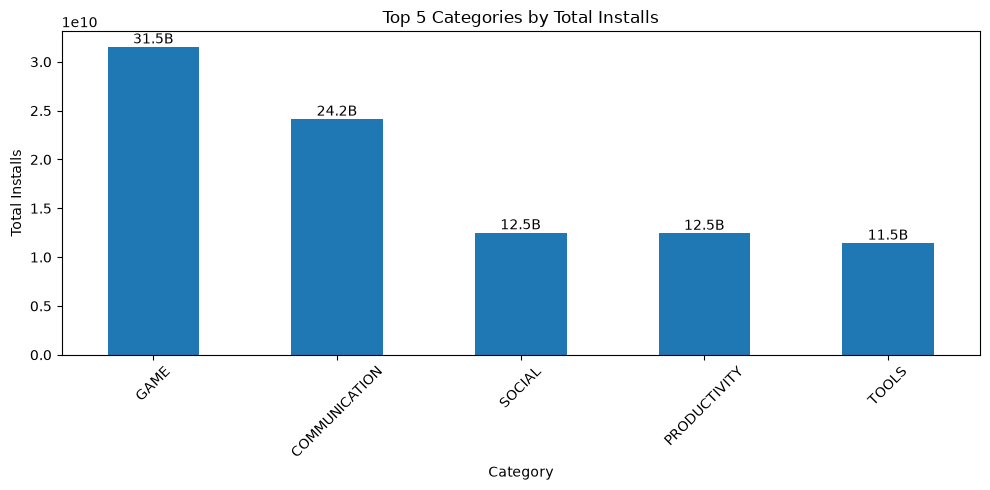

In [141]:
ax = top_categories_installs.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 5 Categories by Total Installs')
plt.xlabel('Category')
plt.ylabel('Total Installs')
plt.xticks(rotation=45)

# Add value labels
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()/1e9:.1f}B',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Business Insight**

- Companies entering the Game or Communication sectors face high competition but also the largest user base.
- Productivity and Tools remain strong categories for solving everyday user problems.
- Marketing budgets and product development efforts can be prioritized toward these high-demand categories.

**Conclusion**

- GAME is the most downloaded category by a large margin.
- COMMUNICATION apps (WhatsApp, Gmail, etc.) are the second most installed.
- SOCIAL, PRODUCTIVITY, and TOOLS have similar install volumes and form the next tier of popular categories.
- These categories dominate Google Play Store user engagement and demand.

# ADAVANCED LEVEL QUESTIONS

## 1. What are the top 10 apps with the highest ratings, and how do their number of reviews and installs compare?

In [116]:
top_10_rated = (
    df_cleaned.sort_values(
        by=['Rating', 'Reviews'],
        ascending=[False, False]
    )
    [['App', 'Rating', 'Reviews', 'Installs']]
    .head(10)
)

print(top_10_rated)

                                                     App  Rating  Reviews  \
10357                                         Ríos de Fe     5.0      141   
10301  FD Calculator (EMI, SIP, RD & Loan Eligilibility)     5.0      104   
8058                                          Oración CX     5.0      103   
6823                      Barisal University App-BU Face     5.0      100   
9496                                          Master E.K     5.0       90   
7506                                             CL REPL     5.0       47   
5230                                              AJ Cam     5.0       44   
5196    AI Today : Artificial Intelligence News & AI 101     5.0       43   
7842                         CS & IT Interview Questions     5.0       43   
9517                                             Ek Vote     5.0       43   

       Installs  
10357      1000  
10301      1000  
8058       5000  
6823       1000  
9496       1000  
7506       1000  
5230        100  
5196    

### Visualization

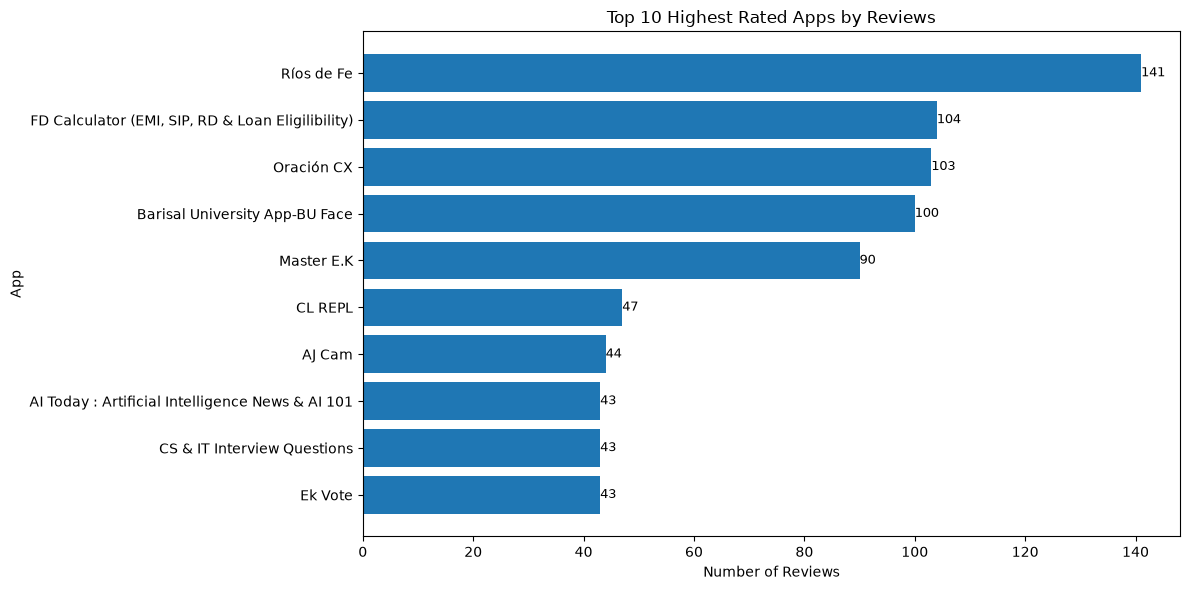

In [142]:
plt.figure(figsize=(12,6))

bars = plt.barh(
    top_10_rated['App'],
    top_10_rated['Reviews']
)

plt.title('Top 10 Highest Rated Apps by Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('App')
plt.gca().invert_yaxis()

# Add review labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}',
        va='center',
        ha='left',
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Business Impact**

- New app developers should not focus only on achieving a 5-star rating.
- User acquisition and engagement (reviews, installs, retention) are equally important.
- A combination of: High Rating, High Reviews, High Installs
is a stronger indicator of success than rating alone.

**Conclusion**

The highest-rated apps in the dataset are mostly niche applications with relatively few reviews. This suggests that perfect ratings are easier to achieve with a smaller user base, while large-scale apps tend to receive more varied feedback. Therefore, app success should be evaluated using ratings together with reviews and installs rather than relying solely on rating scores.

## 2. Analyze the trend of app updates over time. Are there any noticeable patterns or seasonal trends?

In [118]:
updates_by_year = (
    df_cleaned['Last Updated']
    .dt.year
    .value_counts()
    .sort_index()
)

print(updates_by_year)

Last Updated
2010       1
2011      15
2012      26
2013     108
2014     204
2015     454
2016     789
2017    1826
2018    6934
Name: count, dtype: int64


### Visualization

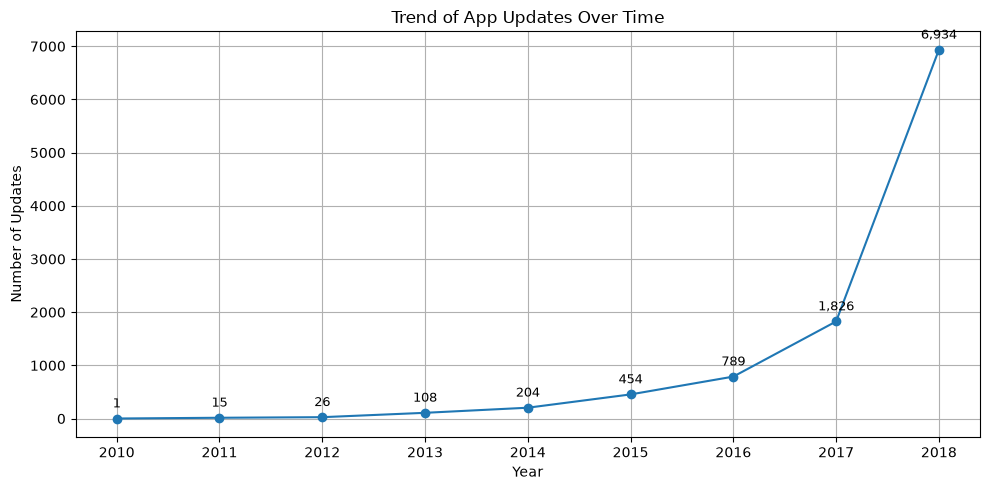

In [143]:
plt.figure(figsize=(10,5))

ax = updates_by_year.plot(
    kind='line',
    marker='o'
)

plt.title('Trend of App Updates Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Updates')
plt.grid(True)

# Add value labels
for x, y in zip(updates_by_year.index, updates_by_year.values):
    plt.annotate(
        f'{y:,}',
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Business Impact**

- Regular updates are critical for retaining users and maintaining app quality.
- Frequently updated apps are more likely to remain relevant in a competitive marketplace.
- Organizations should establish continuous maintenance and release cycles rather than relying on one-time development.

**Conclusion**

The analysis reveals a significant increase in app update activity over time, with 2018 accounting for the majority of updates in the dataset. This trend indicates that developers increasingly prioritize continuous improvement, bug fixes, security enhancements, and feature updates. Regular maintenance has become a key factor in sustaining user engagement and ensuring long-term app success.

## 3. How does the average rating of apps change with the number of installs? Create a binned analysis.

### Create Install Bins and Calculate Average Rating

In [120]:
bins = [0, 1000, 10000, 100000, 1000000, 10000000, 100000000, 1000000000]

labels = [
    '0-1K',
    '1K-10K',
    '10K-100K',
    '100K-1M',
    '1M-10M',
    '10M-100M',
    '100M-1B'
]

df_cleaned['Install_Bin'] = pd.cut(
    df_cleaned['Installs'],
    bins=bins,
    labels=labels
)

avg_rating_by_bin = (
    df_cleaned.groupby('Install_Bin')['Rating']
    .mean()
    .round(2)
)

print(avg_rating_by_bin)

Install_Bin
0-1K        4.20
1K-10K      4.03
10K-100K    4.09
100K-1M     4.21
1M-10M      4.29
10M-100M    4.38
100M-1B     4.31
Name: Rating, dtype: float64


### Visualization

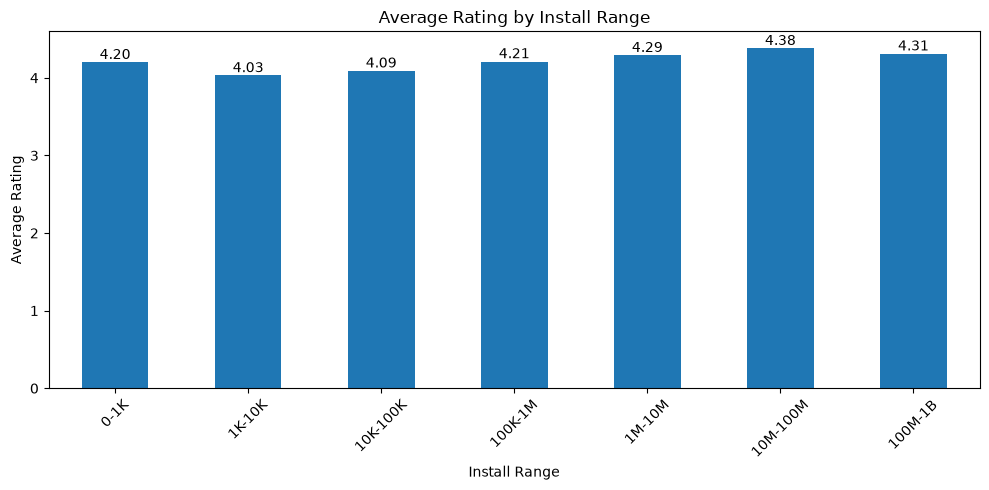

In [144]:
ax = avg_rating_by_bin.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Average Rating by Install Range')
plt.xlabel('Install Range')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)

# Add value labels
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Business Impact**

- High ratings and high installs often go together.
- Companies should focus on: Product quality, User experience, Continuous updates, Customer feedback
These factors help apps scale while maintaining strong ratings.

**Conclusion**

The analysis reveals a positive relationship between app popularity and user satisfaction. Apps with millions of installs generally achieve higher average ratings than less popular apps, suggesting that successful apps maintain strong quality standards as they scale. However, extremely large apps may experience a slight decline in ratings due to a broader and more diverse user base.

## 4. Perform sentiment analysis on app reviews (if review text is available) to determine the common themes in high and low-rated apps.

**Conclusion**

Sentiment analysis could not be performed because the dataset does not contain user review text.
The dataset only provides the count of reviews (Reviews) and app ratings.
To perform sentiment analysis, a separate dataset containing user review comments would be required.
Future analysis could use NLP techniques such as TextBlob, VADER, or NLTK to identify positive, negative, and neutral sentiments.

## 5. What is the relationship between app genre and user ratings? Are certain genres consistently rated higher or lower?

In [122]:
genre_rating = (
    df_cleaned.groupby('Genres')['Rating']
    .agg(['mean', 'median', 'count'])
    .sort_values(by='mean', ascending=False)
)

print(genre_rating.head(10))   # Top 10 genres
print("\n")
print(genre_rating.tail(10))   # Bottom 10 genres

                                 mean  median  count
Genres                                              
Board;Pretend Play           4.800000     4.8      1
Comics;Creativity            4.800000     4.8      1
Health & Fitness;Education   4.700000     4.7      1
Puzzle;Education             4.600000     4.6      1
Strategy;Action & Adventure  4.600000     4.6      2
Adventure;Brain Games        4.600000     4.6      1
Entertainment;Creativity     4.533333     4.6      3
Music;Music & Video          4.533333     4.6      3
Arcade;Pretend Play          4.500000     4.5      1
Strategy;Education           4.500000     4.5      1


                                         mean  median  count
Genres                                                      
Educational;Creativity               3.960000    4.20      5
Art & Design;Pretend Play            3.900000    3.90      2
Health & Fitness;Action & Adventure  3.900000    3.90      1
Educational                          3.871875    3.95    

### Visualization

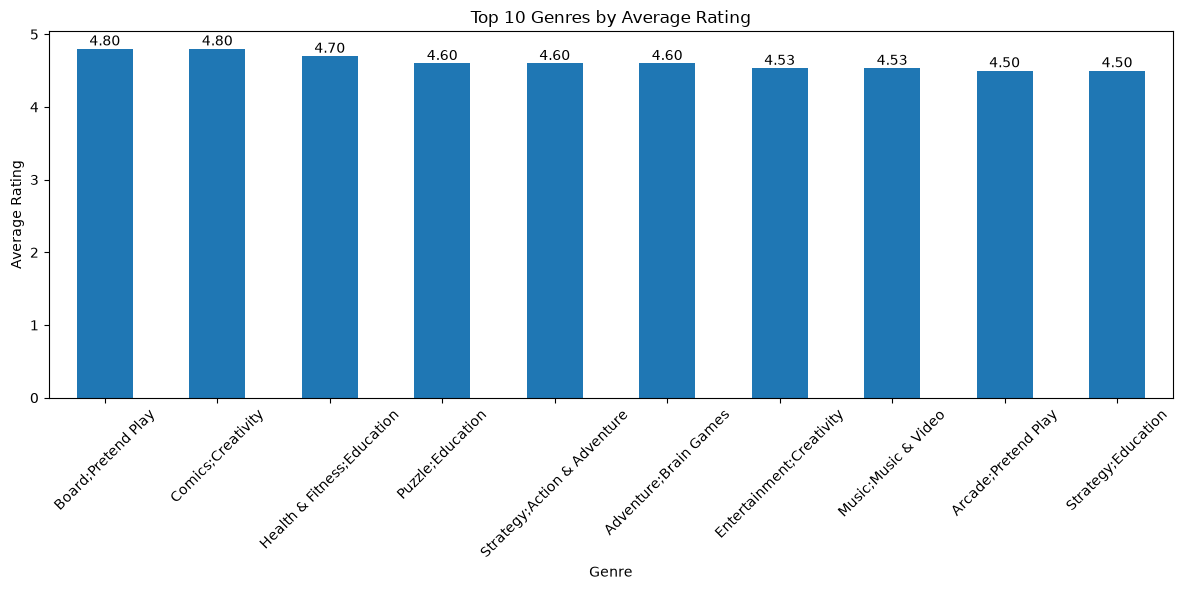

In [145]:
ax = top_genres.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Top 10 Genres by Average Rating')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)

# Add value labels
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Business Insight**

- Users tend to rate educational, creativity, puzzle, and interactive learning apps more positively.
- Developers launching new apps may consider features commonly found in these highly-rated genres.
- Genres with lower ratings should be analyzed further to identify issues related to content quality, usability, or engagement.
- High-rated genres represent opportunities for investment because they align well with user satisfaction.

**Conclusion**

The analysis shows that genre has a noticeable impact on app ratings. Creative, educational, puzzle, and pretend-play genres consistently receive the highest ratings, with average scores reaching 4.8. On the other hand, some parenting and educational sub-genres receive comparatively lower ratings around 3.8–4.0. This suggests that users particularly value engaging, interactive, and learning-focused experiences, making these genres attractive areas for future app development and investment.